In [1]:
from phisolve.utils.file_utils import load_instance
from phisolve.solvers.phi_miqp import PhiMIQP
from phisolve.backends.pdqihd import BackendParams
import jax
import numpy as np

In [2]:
filename = "imrt_instance.npz"

In [3]:
problem_ori, sol = load_instance(filename)

In [4]:
from phisolve.presolvers.highs_milp import HighsMILPPresolver

presolver = HighsMILPPresolver(problem_ori)

problem = presolver.presolve()

Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  has 40906 rows; 41380 cols; 11600624 nonzeros; 40618 integer variables (0 binary)
Presolving model
14393 rows, 762 cols, 4465301 nonzeros  2s
13760 rows, 762 cols, 4242249 nonzeros  4s
Presolve status: Reduced


In [5]:
device = "gpu"

if device == "gpu":
    n_shots = 1
    n_steps = 100000
    inner_loop_steps = 1000
elif device == "cpu":
    n_shots = 10
    n_steps = 2000
    inner_loop_steps = 100

seed = 42

from phisolve.utils.jax_utils import jax_device
jax.config.update("jax_platforms", jax_device(device))

In [6]:
#from phisolve.refiners.highs import HiGHSRefiner
from phisolve.refiners.gurobi import GurobiRefiner
from phisolve.backends.pdqihd import PDQIHD

backend = PDQIHD(n_steps, n_shots, device=device, inner_loop_steps=inner_loop_steps, seed=seed, obj_ratio=10, pdqp_ratio=0.3)
refiner = GurobiRefiner()

solver = PhiMIQP(problem, backend, refiner)

res = solver.solve()

Set parameter Username
Set parameter LicenseID to value 2783515
Academic license - for non-commercial use only - expires 2027-02-25
Set parameter NonConvex to value 2
Set parameter Method to value -1


In [7]:
xs = np.array(res.refined_samples)

def obj(x):
    return problem.w @ x

objs = jax.jit(jax.vmap(obj))(xs)
maxvios = np.array([problem.max_vios(x) for x in xs])
feas = maxvios < 1.5e-3
minima = np.min(objs[feas])
minimizer = np.argmin(objs[feas])
minimizer_vios = maxvios[feas][minimizer]
succ_cnt = (objs[feas] <= minima + 1e-3).sum()
print(minima, minimizer_vios, succ_cnt / n_shots)

0.0 9.947598e-14 1.0


In [8]:
objs, maxvios

(Array([0.], dtype=float32), array([9.947598e-14], dtype=float32))

In [9]:
xs[feas][minimizer].dump("imrt_prostate_sol.npz")

In [10]:
import numpy as np
xf = np.load("imrt_prostate_sol.npz", allow_pickle=True)

In [9]:
v = presolver.postsolve(xs[feas][minimizer])

In [12]:
problem_ori.obj(v)

np.float64(0.0)

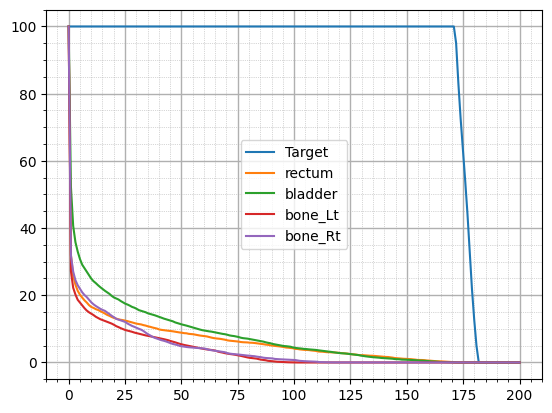

In [ ]:
#DVhcurve plotter

import scipy as sp
import pandas as pd
from jax import numpy as jnp
from jax.experimental.sparse import BCOO
import matplotlib.pyplot as plt

def convert_COO_file_to_jax(file_name, n_cols=None):
    df = pd.read_csv(file_name)

    # Extract the 'row', 'column', and 'value' columns
    rows = df['row'].values
    cols = df['col'].values
    values = df['data'].values

    # Stack the row and column indices to create the indices array
    indices = jnp.vstack((rows, cols)).T  # Shape: (nnz, 2)

    # Convert the values to a JAX array
    data = jnp.array(values)

    # Determine the shape of the matrix (assuming zero-based indexing)
    if n_cols is None:
        shape = (rows.max()+1, cols.max()+1)
    else:
        shape = (rows.max()+1, n_cols)

    # Create the BCOO matrix
    mat = BCOO((data, indices), shape=shape)
    return mat

def plot_DVh_curve(dt_mat, oar1_mat,  oar2_mat,oar3_mat,oar4_mat,structure_names,optimal_intensity, max_dose=200):

    """
    Plots the DVh curve for a given structure.
    """     
    dose={structure_names[0]: dt_mat @ optimal_intensity,
          structure_names[1]: oar1_mat @ optimal_intensity,
          structure_names[2]: oar2_mat @ optimal_intensity,
          structure_names[3]: oar3_mat @ optimal_intensity,
          structure_names[4]: oar4_mat @ optimal_intensity}

    xax = np.linspace(0, max_dose, max_dose)

    plt.figure()
    ax = plt.gca()

    for j in range(len(structure_names)):
        dvh_array = np.zeros((max_dose,1))
        for i in range(max_dose):
            dvh_array[i] = ((dose[structure_names[j]] >= i).sum() / len(dose[structure_names[j]])) * 100
        plt.plot(xax, dvh_array, label=structure_names[j])
    
    plt.legend()
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5')
    ax.grid(which='major', linestyle='-', linewidth='1')

to_scipy = lambda x: sp.sparse.coo_array((x.data, x.indices.transpose()), shape=x.shape)
rectum_mat = convert_COO_file_to_jax('Rectum.csv')
bladder_mat = convert_COO_file_to_jax('Bladder.csv')
bone_Lt_mat = convert_COO_file_to_jax('Bone_Lt.csv')
bone_Rt_mat = convert_COO_file_to_jax('Bone_Rt.csv')
prostate_mat = convert_COO_file_to_jax('Prostate.csv')
n_oars = rectum_mat.shape[0] + bladder_mat.shape[0] + bone_Lt_mat.shape[0] + bone_Rt_mat.shape[0]
weights = v[n_oars : n_oars + prostate_mat.shape[1]]
plot_DVh_curve(to_scipy(prostate_mat), to_scipy(rectum_mat), to_scipy(bladder_mat), to_scipy(bone_Lt_mat), to_scipy(bone_Rt_mat),['Target', 'rectum', 'bladder', 'bone_Lt', 'bone_Rt'],weights,200)

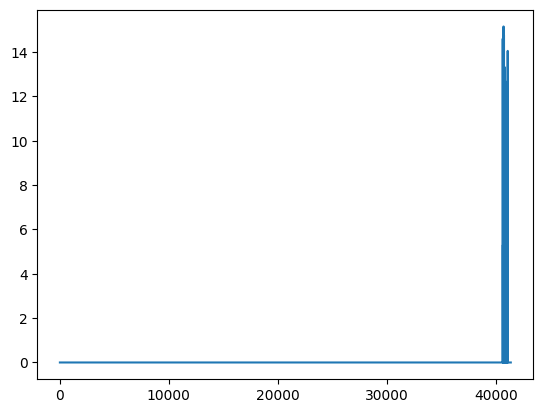

In [ ]:
import matplotlib.pyplot as plt
plt.plot(v)

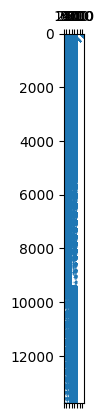

In [12]:
import matplotlib.pyplot as plt

plt.spy(problem.A, markersize=0.1)

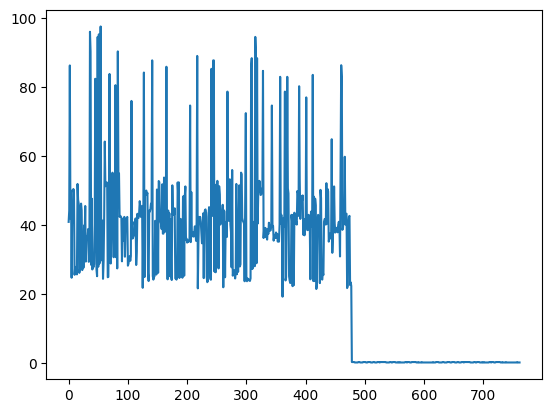

In [13]:
plt.plot(problem.bounds[1])